In [ ]:
!pip install -q transformers torchvision albumentations

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!git clone https://github.com/tangsanli5201/DeepPCB.git

Cloning into 'DeepPCB'...
remote: Enumerating objects: 4753, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4753 (delta 13), reused 12 (delta 12), pack-reused 4739 (from 1)
Receiving objects: 100% (4753/4753), 85.81 MiB | 18.27 MiB/s, done.
Resolving deltas: 100% (191/191), done.
Updating files: 100% (4548/4548), done.


In [ ]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset


class DeepPCBDataset(Dataset):
    def __init__(self, root_dir, split_file):
        self.root_dir = root_dir

        with open(split_file, "r") as f:
            self.samples = [line.strip().split() for line in f.readlines()]

        # 6 clases
        self.classes = ["open", "short", "mousebite", "spur", "copper", "pin-hole"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_rel_path, ann_rel_path = self.samples[idx]

        img_path = os.path.join(
            self.root_dir,
            img_rel_path.replace(".jpg", "_test.jpg")
        )
        ann_path = os.path.join(self.root_dir, ann_rel_path)

        image = Image.open(img_path).convert("RGB")

        annotations = []

        if os.path.exists(ann_path):
            with open(ann_path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    xmin, ymin, xmax, ymax, class_id = parts

                    xmin, ymin, xmax, ymax = map(float, [xmin, ymin, xmax, ymax])
                    class_id = int(class_id)

                    width = xmax - xmin
                    height = ymax - ymin

                    # evitar cajas inválidas
                    if width < 1 or height < 1:
                        continue

                    annotations.append({
                        "bbox": [xmin, ymin, width, height],
                        "category_id": class_id,
                        "area": width * height,
                        "iscrowd": 0
                    })

        target = {
            "image_id": idx,
            "annotations": annotations
        }

        return image, target

In [ ]:
ROOT_DIR = "/content/DeepPCB/PCBData"
SPLIT_FILE = "/content/DeepPCB/PCBData/trainval.txt"

dataset = DeepPCBDataset(ROOT_DIR, SPLIT_FILE)

print("Samples:", len(dataset))
print("Clases:", dataset.classes)

Samples: 1000
Clases: ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']


In [ ]:
img, target = dataset[0]

print(img.size)
print(target)

(640, 640)
{'image_id': 0, 'annotations': [{'bbox': [409.0, 394.0, 26.0, 28.0], 'category_id': 3, 'area': 728.0, 'iscrowd': 0}, {'bbox': [275.0, 383.0, 44.0, 34.0], 'category_id': 3, 'area': 1496.0, 'iscrowd': 0}, {'bbox': [8.0, 163.0, 28.0, 28.0], 'category_id': 4, 'area': 784.0, 'iscrowd': 0}, {'bbox': [244.0, 151.0, 26.0, 31.0], 'category_id': 5, 'area': 806.0, 'iscrowd': 0}, {'bbox': [338.0, 519.0, 26.0, 24.0], 'category_id': 6, 'area': 624.0, 'iscrowd': 0}, {'bbox': [476.0, 460.0, 26.0, 21.0], 'category_id': 4, 'area': 546.0, 'iscrowd': 0}]}


In [ ]:
import torch
from torch.utils.data import random_split

# Fijar semilla para reproducibilidad
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 800
Test size: 200


In [ ]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor

# Processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Mapeo de clases (6 defectos)
id2label = {
    0: "open",
    1: "short",
    2: "mousebite",
    3: "spur",
    4: "copper",
    5: "pin-hole",
}

label2id = {v: k for k, v in id2label.items()}

# Modelo con 6 clases
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Modelo listo en:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsam

Modelo listo en: cuda


In [ ]:
from torch.utils.data import DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

def collate_fn(batch):
    images = [item[0] for item in batch]
    annotations = [item[1] for item in batch]

    encoding = processor(
        images=images,
        annotations=annotations,
        return_tensors="pt"
    )

    return {
        "pixel_values": encoding["pixel_values"],
        "labels": encoding["labels"]
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print("Collate y loaders listos")

Collate y loaders listos


In [ ]:
!pip install torchmetrics
import torch
import json
import os
from torch.utils.data import DataLoader, random_split
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
from google.colab import drive

# =========================
# DRIVE
# =========================
drive.mount('/content/drive')

# =========================
# CONFIG
# =========================
lr = 5e-5
batch_size = 4
epochs = 30
patience = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# =========================
# SAVE DIR
# =========================
save_dir = "/content/drive/MyDrive/entrenamiento_detr"
os.makedirs(save_dir, exist_ok=True)

# =========================
# SPLIT DATASET
# =========================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

# =========================
# HISTORIAL
# =========================
history = {
    "train_loss": [],
    "val_loss": [],
    "map": [],
    "map_50": [],
    "map_75": [],
    "iou": []
}

config = {
    "learning_rate": lr,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "AdamW"
}

# =========================
# BEST MODEL + EARLY STOP
# =========================
best_val_loss = float("inf")
epochs_no_improve = 0

# =========================
# TRAIN LOOP
# =========================
for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    total_train_loss = 0.0

    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)

        labels = [
            {k: v.to(device) for k, v in t.items()}
            for t in batch["labels"]
        ]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / max(len(train_loader), 1)

    # -------- VALIDATION --------
    model.eval()
    total_val_loss = 0.0

    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    total_iou = 0.0
    total_boxes = 0

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)

            labels = [
                {k: v.to(device) for k, v in t.items()}
                for t in batch["labels"]
            ]

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

            outputs_pred = outputs

            target_sizes = torch.stack([
                t["orig_size"] for t in batch["labels"]
            ]).to(device)

            results = processor.post_process_object_detection(
                outputs_pred,
                threshold=0.01,
                target_sizes=target_sizes
            )

            preds = []
            targets = []

            for i in range(len(results)):

                pred_boxes = results[i]["boxes"].cpu()

                # ===== GT CORREGIDO =====
                gt_boxes = batch["labels"][i]["boxes"].clone()
                h, w = batch["labels"][i]["orig_size"]

                if gt_boxes.max() <= 1.0:
                    cx, cy, bw, bh = gt_boxes.unbind(1)
                    x1 = cx - 0.5 * bw
                    y1 = cy - 0.5 * bh
                    x2 = cx + 0.5 * bw
                    y2 = cy + 0.5 * bh
                    gt_boxes = torch.stack([x1, y1, x2, y2], dim=1)

                    gt_boxes[:, [0, 2]] *= w
                    gt_boxes[:, [1, 3]] *= h

                gt_boxes = gt_boxes.cpu()

                preds.append({
                    "boxes": pred_boxes,
                    "scores": results[i]["scores"].cpu(),
                    "labels": results[i]["labels"].cpu()
                })

                targets.append({
                    "boxes": gt_boxes,
                    "labels": batch["labels"][i]["class_labels"].cpu()
                })

                # ===== IoU CORRECTO =====
                if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                    ious = box_iou(pred_boxes, gt_boxes)
                    max_ious, _ = ious.max(dim=1)

                    valid = max_ious > 0.5

                    if valid.sum() > 0:
                        total_iou += max_ious[valid].sum().item()
                        total_boxes += valid.sum().item()

            # SOLO actualizar si hay predicciones válidas
            if any(len(p["boxes"]) > 0 for p in preds):
                metric.update(preds, targets)

    avg_val_loss = total_val_loss / max(len(val_loader), 1)
    avg_iou = total_iou / max(total_boxes, 1)

    metrics_result = metric.compute()
    map_score = metrics_result["map"].item()
    map_50 = metrics_result["map_50"].item()
    map_75 = metrics_result["map_75"].item()

    # -------- HISTORIAL --------
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["map"].append(map_score)
    history["map_50"].append(map_50)
    history["map_75"].append(map_75)
    history["iou"].append(avg_iou)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"mAP: {map_score:.4f} | mAP@50: {map_50:.4f} | mAP@75: {map_75:.4f} | IoU: {avg_iou:.4f}")

    # -------- GUARDAR --------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_loss": avg_val_loss,
            "map": map_score,
            "iou": avg_iou
        }, os.path.join(save_dir, "best_model.pth"))

        print("Mejor modelo guardado")

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("Early stopping activado")
        break

# =========================
# GUARDADO FINAL
# =========================
torch.save(model.state_dict(), os.path.join(save_dir, "model_final.pth"))

with open(os.path.join(save_dir, "history.json"), "w") as f:
    json.dump(history, f)

with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config, f)

print("Todo guardado en Drive")

Mounted at /content/drive
Train batches: 200
Val batches: 50

Epoch 1/30
Train Loss: 2.4146 | Val Loss: 1.8975
mAP: 0.0087 | mAP@50: 0.0183 | mAP@75: 0.0067 | IoU: 0.7107
Mejor modelo guardado

Epoch 2/30
Train Loss: 1.8731 | Val Loss: 1.7627
mAP: 0.0205 | mAP@50: 0.0396 | mAP@75: 0.0183 | IoU: 0.7296
Mejor modelo guardado

Epoch 3/30
Train Loss: 1.7994 | Val Loss: 1.5660
mAP: 0.0304 | mAP@50: 0.0562 | mAP@75: 0.0298 | IoU: 0.7400
Mejor modelo guardado

Epoch 4/30
Train Loss: 1.5880 | Val Loss: 1.5458
mAP: 0.0437 | mAP@50: 0.0737 | mAP@75: 0.0434 | IoU: 0.7559
Mejor modelo guardado

Epoch 5/30
Train Loss: 1.5347 | Val Loss: 1.4846
mAP: 0.0447 | mAP@50: 0.0802 | mAP@75: 0.0430 | IoU: 0.7465
Mejor modelo guardado

Epoch 6/30
Train Loss: 1.4760 | Val Loss: 1.3960
mAP: 0.0832 | mAP@50: 0.1371 | mAP@75: 0.0900 | IoU: 0.7679
Mejor modelo guardado

Epoch 7/30
Train Loss: 1.3828 | Val Loss: 1.2979
mAP: 0.1359 | mAP@50: 0.2228 | mAP@75: 0.1509 | IoU: 0.7632
Mejor modelo guardado

Epoch 8/30
Tra

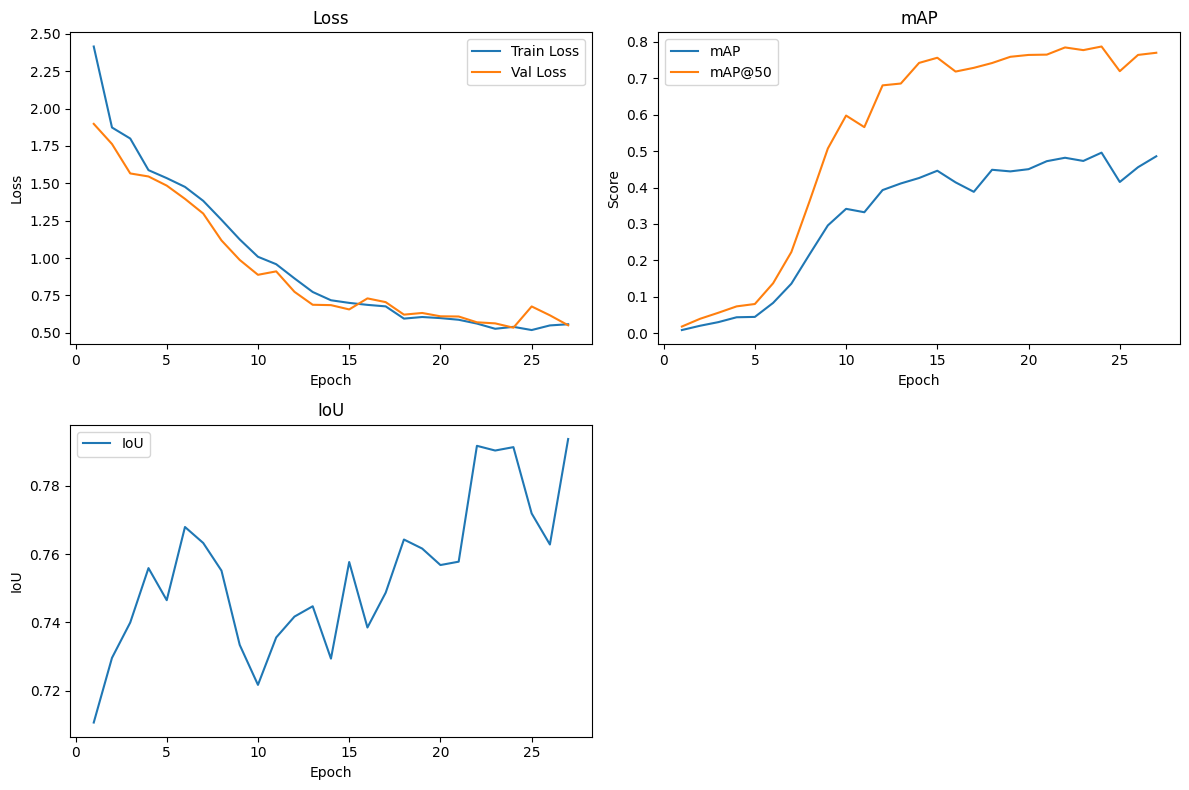

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 8))

# ---- LOSS ----
plt.subplot(2, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# ---- mAP ----
plt.subplot(2, 2, 2)
plt.plot(epochs, history["map"], label="mAP")
plt.plot(epochs, history["map_50"], label="mAP@50")
plt.title("mAP")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

# ---- IoU ----
plt.subplot(2, 2, 3)
plt.plot(epochs, history["iou"], label="IoU")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()

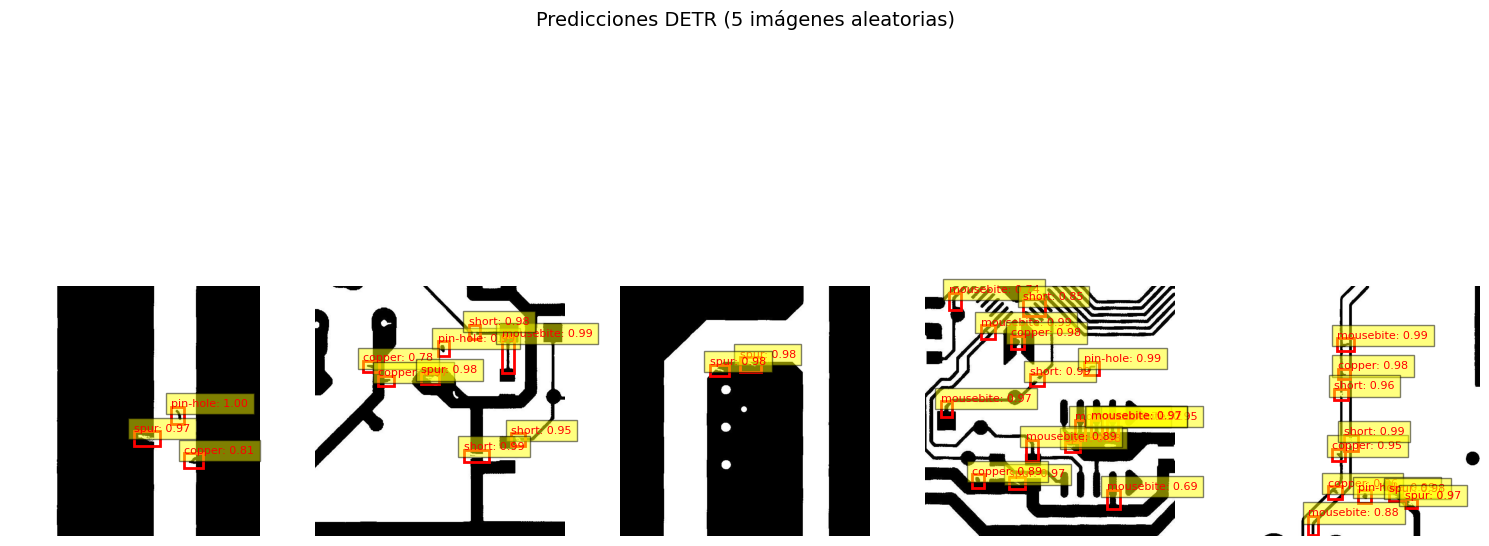

In [ ]:
import torch
import matplotlib.pyplot as plt
import random

# Poner el modelo en modo evaluación
model.eval()

num_images = 5  # cantidad de imágenes a mostrar

# Elegir índices aleatorios
indices = random.sample(range(len(dataset)), num_images)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(indices):
    image, target = dataset[idx]

    # Preprocesamiento
    inputs = processor(images=[image], return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Post-processing
    results = processor.post_process_object_detection(
        outputs,
        target_sizes=[(image.size[1], image.size[0])],  # (h, w)
        threshold=0.5
    )[0]

    # Subplot
    plt.subplot(1, num_images, i + 1)
    plt.imshow(image)
    ax = plt.gca()

    # Si no hay detecciones
    if len(results["boxes"]) == 0:
        ax.set_title("Sin detecciones", fontsize=10)

    # Dibujar predicciones
    for score, label, box in zip(
        results["scores"],
        results["labels"],
        results["boxes"]
    ):
        xmin, ymin, xmax, ymax = box.cpu().numpy()

        # Bounding box
        ax.add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
        )

        # Label + score
        class_name = model.config.id2label[label.item()]
        score_value = score.item()

        ax.text(
            xmin,
            ymin,
            f"{class_name}: {score_value:.2f}",
            color="red",
            fontsize=8,
            bbox=dict(facecolor="yellow", alpha=0.5)
        )

    ax.axis("off")

plt.suptitle("Predicciones DETR (5 imágenes aleatorias)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# YOLO vs DETR - DEEPCB REAL (POR GRUPOS)
# =========================

from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics opencv-python -q

import os
import cv2
import shutil
import random
from ultralytics import YOLO

base_path = "DeepPCB/PCBData"

# =========================
# CREAR DATASET YOLO
# =========================
base_dir = "yolo_dataset"
train_img = os.path.join(base_dir, "images/train")
val_img = os.path.join(base_dir, "images/val")
train_lbl = os.path.join(base_dir, "labels/train")
val_lbl = os.path.join(base_dir, "labels/val")

for d in [train_img, val_img, train_lbl, val_lbl]:
    os.makedirs(d, exist_ok=True)

# =========================
# FUNCION CONVERSION
# =========================
def convert_to_yolo(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]

    x_center = (box[0] + box[2]) / 2.0
    y_center = (box[1] + box[3]) / 2.0
    w = box[2] - box[0]
    h = box[3] - box[1]

    return x_center*dw, y_center*dh, w*dw, h*dh

# =========================
# RECOLECTAR DATASET
# =========================
samples = []

for group in os.listdir(base_path):
    group_path = os.path.join(base_path, group)
    if not os.path.isdir(group_path):
        continue

    subdirs = os.listdir(group_path)
    img_dir = None
    lbl_dir = None

    for d in subdirs:
        if d.endswith("_not"):
            lbl_dir = os.path.join(group_path, d)
        else:
            img_dir = os.path.join(group_path, d)

    if img_dir is None or lbl_dir is None:
        continue

    for file in os.listdir(lbl_dir):
        if not file.endswith(".txt"):
            continue

        img_name = file.replace(".txt", "_test.jpg")

        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, file)

        if os.path.exists(img_path):
            samples.append((img_path, lbl_path))

print("Total samples:", len(samples))

# =========================
# SPLIT
# =========================
random.shuffle(samples)
split = int(0.8 * len(samples))

train_samples = samples[:split]
val_samples = samples[split:]

# =========================
# PROCESAR
# =========================
def process(samples, img_out, lbl_out):
    for img_path, lbl_path in samples:
        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        yolo_lines = []
        for line in lines:
            xmin, ymin, xmax, ymax, cls = map(int, line.strip().split())
            x, y, bw, bh = convert_to_yolo((w, h), (xmin, ymin, xmax, ymax))
            yolo_lines.append(f"{cls} {x} {y} {bw} {bh}\n")

        name = os.path.basename(img_path)

        with open(os.path.join(lbl_out, name.replace(".jpg", ".txt")), "w") as f:
            f.writelines(yolo_lines)

        shutil.copy(img_path, os.path.join(img_out, name))

print("Procesando TRAIN...")
process(train_samples, train_img, train_lbl)

print("Procesando VAL...")
process(val_samples, val_img, val_lbl)

# =========================
# YAML
# =========================
yaml_path = "/content/drive/MyDrive/dataset_yolo_deeppcb.yaml"

with open(yaml_path, "w") as f:
    f.write(f"""
path: /content/yolo_dataset
train: images/train
val: images/val

names:
  0: open
  1: short
  2: mousebite
  3: spur
  4: copper
  5: pinhole
""")

print("YAML listo.")

# =========================
# ENTRENAR YOLO
# =========================
model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640
)

# =========================
# EVALUACION
# =========================
metrics = model.val()

print("\n=== YOLO RESULTADOS ===")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

# =========================
# COMPARACION FINAL
# =========================
print("\n=== DETR vs YOLO ===")

try:
    print("DETR mAP:", history["map"][-1])
except:
    print("DETR mAP: no disponible")

print("YOLO mAP50:", metrics.box.map50)
print("YOLO mAP50-95:", metrics.box.map)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total samples: 1500
Procesando TRAIN...
Procesando VAL...
YAML listo.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset_yolo_deeppcb.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, 